<a href="https://colab.research.google.com/github/chaiyawat19/DataScinceLab/blob/main/Lab5_diabetes_decisiontree_EvaluationModels.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('/content/diabetes.csv')

In [ ]:
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [ ]:
df.Outcome.astype('category')

0      1
1      0
2      1
3      0
4      1
      ..
763    0
764    0
765    0
766    1
767    0
Name: Outcome, Length: 768, dtype: category
Categories (2, int64): [0, 1]

In [ ]:
df.dtypes

Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

In [ ]:
from sklearn.tree import DecisionTreeClassifier, export_graphviz
from sklearn import tree
x = df.drop(['Outcome'],axis=1)
y = df.Outcome

In [ ]:
y.shape

(768,)

# Train Test Split

In [ ]:
from sklearn.model_selection import train_test_split
# Split dataset into training set and test set
train_data, test_data, train_y, test_y = train_test_split(x, y, test_size=0.20, shuffle=False)

In [ ]:
# Create Decision Tree classifer object
decision_tree_classifier = DecisionTreeClassifier(criterion="entropy")

# Train Decision Tree Classifer
decision_tree_classifier.fit(train_data,train_y)

y_predict = decision_tree_classifier.predict(test_data)
y_predict

array([1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1,
       0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1,
       1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0,
       1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0])

In [ ]:
from sklearn import metrics
print("Accuracy:",metrics.accuracy_score(test_y,y_predict))

Accuracy: 0.6558441558441559


In [ ]:
from sklearn.metrics import classification_report,confusion_matrix

print(classification_report(test_y,y_predict))

              precision    recall  f1-score   support

           0       0.73      0.75      0.74        99
           1       0.52      0.49      0.50        55

    accuracy                           0.66       154
   macro avg       0.62      0.62      0.62       154
weighted avg       0.65      0.66      0.65       154



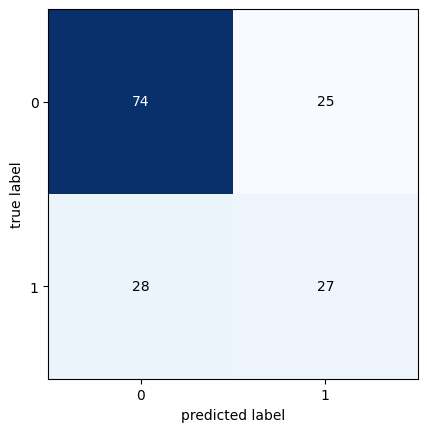

In [ ]:
import matplotlib.pyplot as plt
from mlxtend.plotting import plot_confusion_matrix
cm = confusion_matrix(test_y,y_predict)
fig, ax = plot_confusion_matrix(conf_mat=cm)
plt.show()

# K-fold Cross Validation

In [ ]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(decision_tree_classifier, x, y, cv=5, scoring="accuracy")

print("Average CV Accuracy Score: ", scores.mean())

Average CV Score:  0.6784738137679314


In [ ]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(decision_tree_classifier, x, y, cv=5, scoring="precision")

print("Average CV precision Score: ", scores.mean())

Average CV precision Score:  0.5519330488553091


In [ ]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(decision_tree_classifier, x, y, cv=5, scoring="recall")

print("Average CV recall Score: ", scores.mean())

Average CV recall Score:  0.5561146051712089


In [ ]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(decision_tree_classifier, x, y, cv=5, scoring="f1")

print("Average CV F1-Score: ", scores.mean())

Average CV F1-Score:  0.5416067749760473
